# Лабораторна робота №1
## Виконав: Давидчук Артем, група ІО-41

### Мета роботи

Ознайомитися з поданням комп’ютерної мережі у вигляді зваженого неорієнтованого графа, навчитися генерувати квадратну топологію, візуалізувати її та видаляти ребра зі збереженням зв’язності графа.

### Опис алгоритму

Комп’ютерна мережа подається графом $G=(V,E)$, де $V$ — множина вузлів, а $E$ — множина каналів зв’язку. Для $n=k^2$ вузлів формується квадратна решітка розміру $k \times k$. Вузол зберігається як кортеж `(row, col)` та отримує адресу `10.0.row.col`. Ребра створюються лише між горизонтальними й вертикальними сусідами: праворуч і вниз, що для неорієнтованого графа запобігає дублюванню. Кожному ребру призначається випадкова ціла вага — затримка в мілісекундах.

Для видалення ребер їхній список перемішується. Чергове ребро тимчасово видаляється, після чого `nx.is_connected()` перевіряє, чи існує шлях між кожною парою вузлів. Якщо граф став незв’язним, ребро відновлюється з початковою вагою; інакше видалення зараховується. Решітка має $2k(k-1)$ ребер, а зв’язний граф із $k^2$ вузлами потребує щонайменше $k^2-1$ ребер, тому максимально можна видалити $2k(k-1)-(k^2-1)=(k-1)^2$ ребер.

### Імпорт бібліотек

In [49]:
import math
import random

import matplotlib.pyplot as plt
import networkx as nx

### Функції валідації, створення графа, відображення графа та видалення ребер графа

In [50]:
def validate_args(nodes_num, edges_to_delete, min_weight, max_weight):
    k = math.isqrt(nodes_num)
    if k * k != nodes_num:
        raise ValueError("nodes_num must be a perfect square")
    max_edges_to_delete = (k - 1) ** 2

    if edges_to_delete < 0 or edges_to_delete > max_edges_to_delete:
        raise ValueError(f"edges_to_delete must be between 0 and {max_edges_to_delete}")

    if min_weight <= 0 or min_weight > max_weight:
        raise ValueError("invalid weight range")

    print("Arguments validated")


def create_graph(nodes_num=25, min_weight=1, max_weight=10):
    k = math.isqrt(nodes_num)
    nodes = []
    edges = []
    for i in range(k):
        for j in range(k):
            nodes.append((i, j))

    for node in nodes:
        i, j = node
        if i + 1 < k:
            weight = random.randint(min_weight, max_weight)
            edges.append(
                (
                    node,
                    (i + 1, j),
                    weight
                )
            )

        if j + 1 < k:
            weight = random.randint(min_weight, max_weight)
            edges.append(
                (
                    node,
                    (i, j + 1),
                    weight
                )
            )

    graph = nx.Graph()

    for node in nodes:
        graph.add_node(
            node,
            address=f"10.0.{node[0]}.{node[1]}"
        )

    for u, v, weight in edges:
        graph.add_edge(u, v, weight=weight)

    print("Graph successfully created")

    return graph


def show_graph(graph):

    pos = {}
    labels = {}

    for node in graph.nodes():
        i, j = node
        pos[node] = (j, -i)

    for node in graph.nodes():
        labels[node] = graph.nodes[node]["address"]

    plt.figure(figsize=(10, 8))

    nx.draw(
        graph,
        pos,
        labels=labels,
        with_labels=True,
        node_size=1600,
        font_size=8
    )

    edge_labels = nx.get_edge_attributes(
        graph,
        "weight"
    )

    nx.draw_networkx_edge_labels(
        graph,
        pos,
        edge_labels=edge_labels,
        font_size=8
    )

    plt.show()


def remove_edges(graph, m):

    edges = list(graph.edges())
    random.shuffle(edges)

    removed = 0

    while removed < m:

        edge = edges.pop()
        edge_weight = graph[edge[0]][edge[1]]["weight"]

        graph.remove_edge(edge[0], edge[1])

        if nx.is_connected(graph):
            removed += 1
        else:
            graph.add_edge(edge[0], edge[1], weight=edge_weight)

    print(f"Successfully deleted {m} edges")

### Параметри генерації

In [51]:
nodes_num = 25
edges_to_delete = 6
min_weight = 1
max_weight = 10

validate_args(nodes_num, edges_to_delete, min_weight, max_weight)

Arguments validated


### Початкова топологія

In [52]:
graph = create_graph(nodes_num, min_weight, max_weight)
initial_edges = graph.number_of_edges()

Graph successfully created


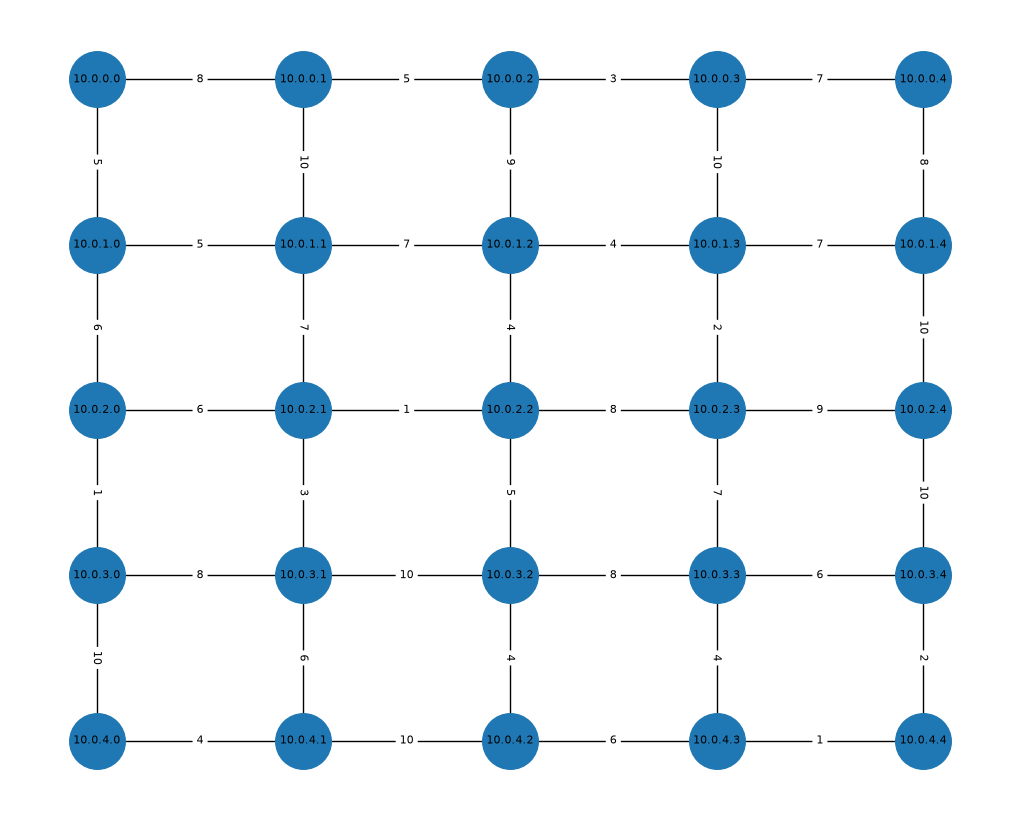

In [53]:
show_graph(graph)

### Видалення ребер

In [54]:
remove_edges(graph, edges_to_delete)

Successfully deleted 6 edges


### Результуюча топологія

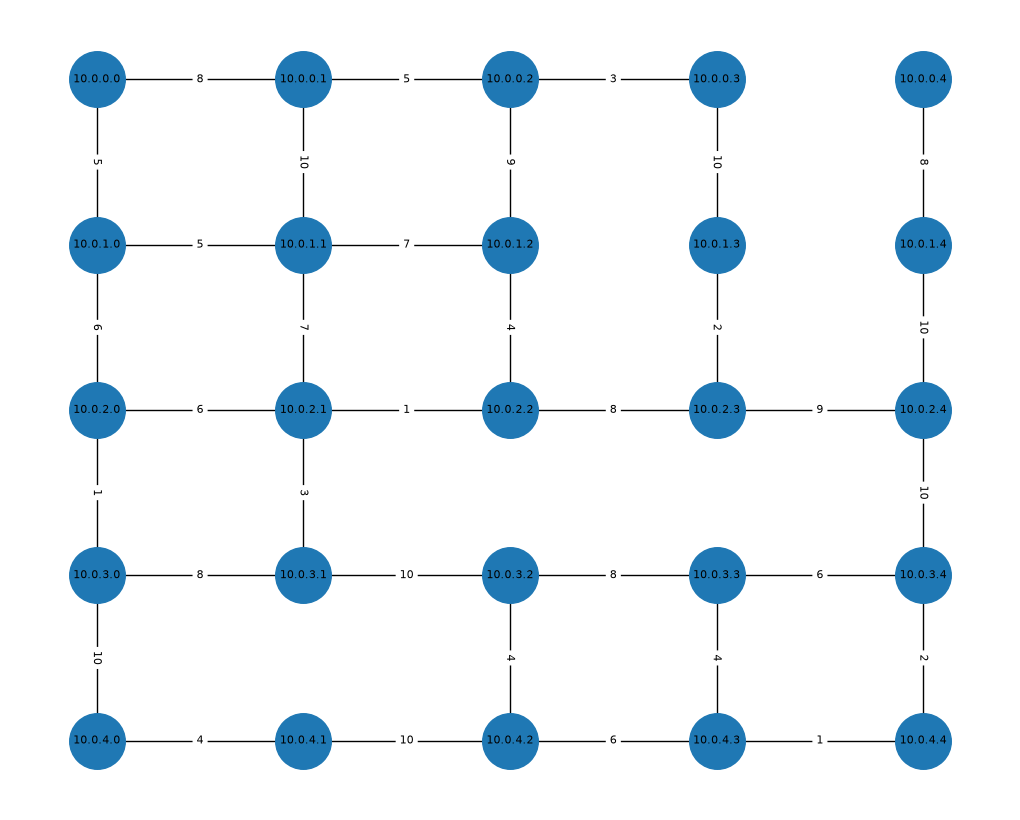

In [55]:
show_graph(graph)

In [56]:
expected_edges = initial_edges - edges_to_delete
is_connected = nx.is_connected(graph)

assert graph.number_of_edges() == expected_edges
assert is_connected

print(f"Кількість вузлів: {graph.number_of_nodes()}")
print(f"Кількість ребер: {graph.number_of_edges()}")
print(f"Граф зв’язний: {is_connected}")

Кількість вузлів: 25
Кількість ребер: 34
Граф зв’язний: True


## Висновок

У роботі згенеровано зважений неорієнтований граф у формі квадратної решітки. Вузли отримали унікальні адреси відповідно до позицій, а ребра — випадкові ваги затримки. З графа видалено задану кількість ребер зі збереженням його зв’язності. Для подання графа використано NetworkX, а для візуалізації — matplotlib.